In [2]:
import tensorflow as tf
from pathlib import Path

In [3]:
BASE_DIR = Path("../../")

TRAIN_DIR = BASE_DIR / "dataset/classification/train"
VAL_DIR = BASE_DIR / "dataset/classification/val"
TEST_DIR = BASE_DIR / "dataset/classification/test"

Found 1080 files belonging to 2 classes.


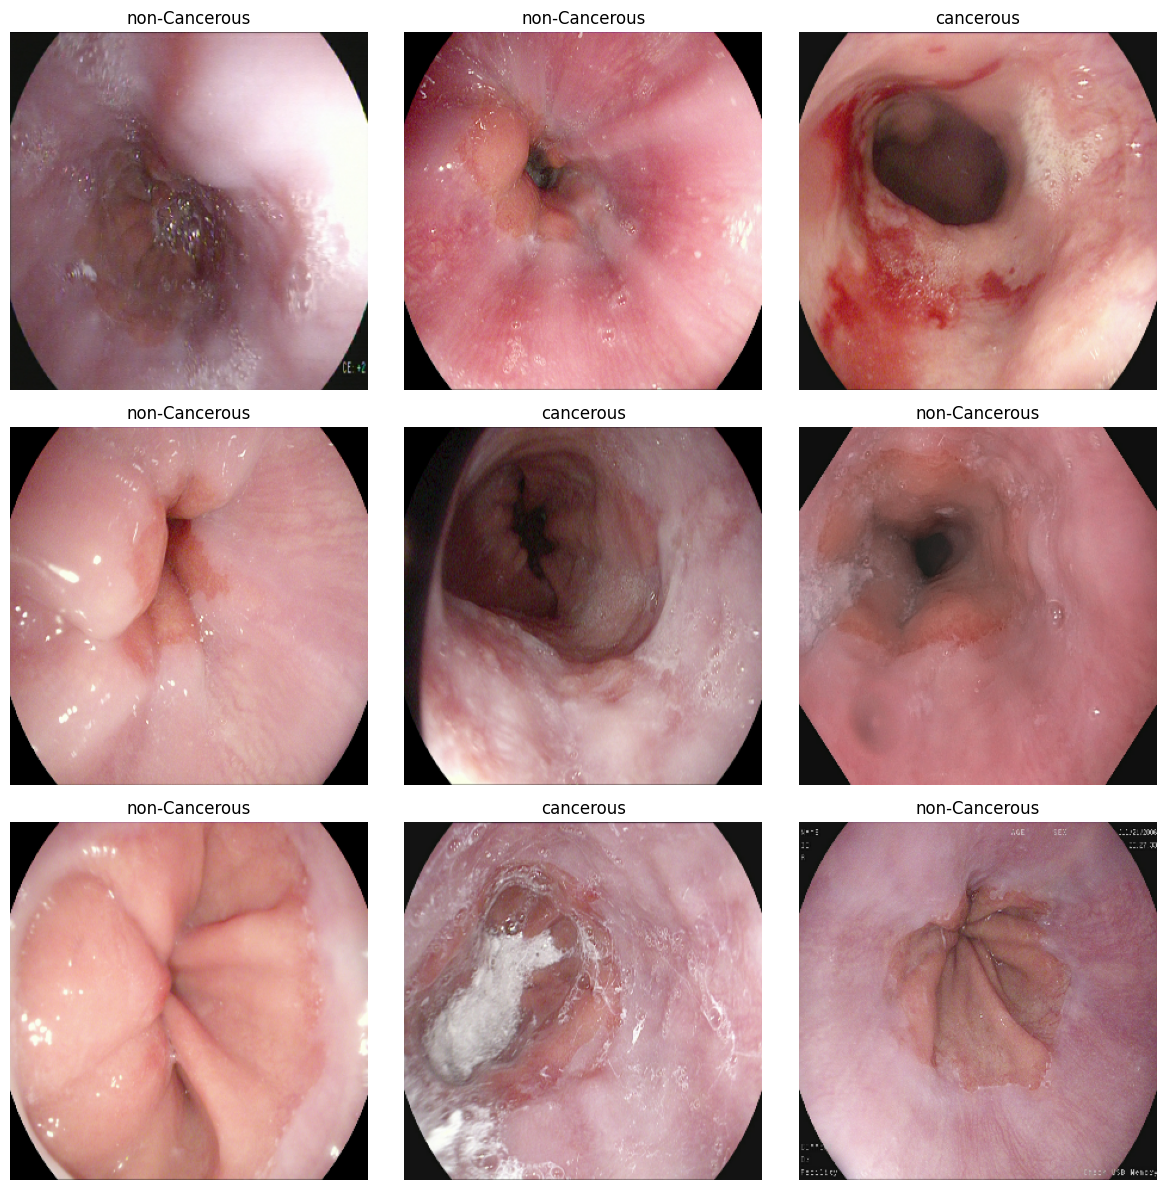

Found 270 files belonging to 2 classes.
Found 339 files belonging to 2 classes.


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(300, 300),
    batch_size=16,
    label_mode="binary"
)
# Save class names
class_names = train_dataset.class_names


# Get one batch
images, labels = next(iter(train_dataset))

# Plot images
plt.figure(figsize=(12,12))

for i in range(9):

    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    label = int(labels[i].numpy()[0])

    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(300,300),
    batch_size=8,
    label_mode="binary"
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(300,300),
    batch_size=8,
    label_mode="binary"
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)

val_dataset = val_dataset.cache().prefetch(AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

# Save class names BEFORE prefetch

In [6]:
class_names
# 0 - cancerous, 1 - non-Cancerous

['cancerous', 'non-Cancerous']

In [7]:
import pandas as pd
import tensorflow as tf

print("Loading all trained models for test evaluation...")
model_eff = tf.keras.models.load_model("../../models/classification/best_model_latest.keras")
model_dense = tf.keras.models.load_model("../../models/classification/best_model_Dense.keras")
model_hybrid = tf.keras.models.load_model("../../models/classification/hybrid_best_model.keras")
print("All models loaded successfully!\n")

print("Evaluating EfficientNetB0...")
results_eff = model_eff.evaluate(test_dataset, verbose=0)

print("Evaluating DenseNet121...")
results_dense = model_dense.evaluate(test_dataset, verbose=0)

print("Evaluating Hybrid Fusion Model...")
results_hybrid = model_hybrid.evaluate(test_dataset, verbose=0)

models_list = ["EfficientNetB0 (Standalone)", "DenseNet121 (Standalone)", "Hybrid Fusion (EffNet + DenseNet)"]
all_results = [results_eff, results_dense, results_hybrid]

accuracy_list = [res[1] * 100 for res in all_results]
precision_list = [res[2] * 100 for res in all_results]
recall_list = [res[3] * 100 for res in all_results]
auc_list = [res[4] for res in all_results]

metrics_data = {
    "Model Name": models_list,
    "Test Accuracy (%)": accuracy_list,
    "Test AUC Score": auc_list,
    "Test Precision (%)": precision_list,
    "Test Recall (%)": recall_list
}

df_metrics = pd.DataFrame(metrics_data)

df_styled = df_metrics.style.highlight_max(
    subset=["Test Accuracy (%)", "Test AUC Score", "Test Precision (%)", "Test Recall (%)"], 
    color="#d4edda", 
    axis=0
).format({
    "Test Accuracy (%)": "{:.2f}%",
    "Test AUC Score": "{:.4f}",
    "Test Precision (%)": "{:.2f}%",
    "Test Recall (%)": "{:.2f}%"
})

print("\n📊 Real-Time Models Comparison Matrix Generated directly from Weights:")
display(df_styled)

df_metrics.to_csv("live_classification_comparison.csv", index=False)

Loading all trained models for test evaluation...
All models loaded successfully!

Evaluating EfficientNetB0...
Evaluating DenseNet121...
Evaluating Hybrid Fusion Model...

📊 Real-Time Models Comparison Matrix Generated directly from Weights:


,Model Name,Test Accuracy (%),Test AUC Score,Test Precision (%),Test Recall (%)
0,EfficientNetB0 (Standalone),79.06%,0.8630,76.13%,90.37%
1,DenseNet121 (Standalone),74.63%,0.8377,71.13%,90.91%
2,Hybrid Fusion (EffNet + DenseNet),76.40%,0.8491,73.78%,88.77%


In [10]:
import os
import pandas as pd


def extract_specific_yolo_runs(base_path, start_run=6, end_run=11):
    all_run_data = []

    if not os.path.exists(base_path):
        return pd.DataFrame()

    target_folders = [f"train-{i}" for i in range(start_run, end_run + 1)]

    for folder in target_folders:
        folder_path = os.path.join(base_path, folder)
        csv_path = os.path.join(folder_path, "results.csv")

        if os.path.isdir(folder_path) and os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                df.columns = df.columns.str.strip()

                if len(df) > 0:
                    final_epoch = df.iloc[-1]
                    version_num = folder.split("-")[-1]

                    display_name = f"YOLOv8m-seg_v{version_num}"
                    if folder == "train-11":
                        display_name += " ⭐ [Final Optimized]"
                    elif folder == "train-10":
                        display_name += " 📋 [Baseline]"

                    metrics = {
                        "YOLO Model Version": display_name,
                        "Box mAP50 (%)": final_epoch["metrics/mAP50(B)"] * 100,
                        "Box mAP50-95 (%)": final_epoch["metrics/mAP50-95(B)"]
                        * 100,
                        "Mask mAP50 (%)": final_epoch["metrics/mAP50(M)"] * 100,
                        "Mask mAP50-95 (%)": final_epoch["metrics/mAP50-95(M)"]
                        * 100,
                    }
                    all_run_data.append(metrics)
            except Exception as e:
                pass

    if not all_run_data:
        return pd.DataFrame()

    df_seg = pd.DataFrame(all_run_data)
    return df_seg


runs_directory = r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment"

df_final_seg = extract_specific_yolo_runs(runs_directory, start_run=6, end_run=11)

if not df_final_seg.empty:
    df_final_styled = df_final_seg.style.highlight_max(
        subset=[
            "Box mAP50 (%)",
            "Box mAP50-95 (%)",
            "Mask mAP50 (%)",
            "Mask mAP50-95 (%)",
        ],
        color="#d4edda",
        axis=0,
    ).format(
        {
            "Box mAP50 (%)": "{:.2f}%",
            "Box mAP50-95 (%)": "{:.2f}%",
            "Mask mAP50 (%)": "{:.2f}%",
            "Mask mAP50-95 (%)": "{:.2f}%",
        }
    )

    display(df_final_styled)
    df_final_seg.to_csv("segmentation_core_runs_comparison.csv", index=False)

,YOLO Model Version,Box mAP50 (%),Box mAP50-95 (%),Mask mAP50 (%),Mask mAP50-95 (%)
0,YOLOv8m-seg_v6,94.75%,76.21%,95.95%,76.31%
1,YOLOv8m-seg_v7,82.35%,53.17%,83.51%,55.27%
2,YOLOv8m-seg_v8,93.01%,74.85%,94.01%,77.01%
3,YOLOv8m-seg_v9,83.51%,56.65%,85.81%,60.08%
4,YOLOv8m-seg_v10 📋 [Baseline],92.86%,75.41%,93.20%,77.13%
5,YOLOv8m-seg_v11 ⭐ [Final Optimized],92.87%,74.28%,94.21%,75.65%
